In [1]:
import os
import tempfile
# conda activate DestVI
import anndata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scvi
import seaborn as sns
import torch

/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = sc.read_h5ad('/maiziezhou_lab2/yuling/Datasets/Development.h5ad')
data.obs['Batch'].unique()

/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


['Stage44_telencephalon_rep2_FP200000239BL_E4', 'Stage54_telencephalon_rep2_DP8400015649BRD6_2', 'Stage57_telencephalon_rep2_DP8400015649BRD5_1', 'Injury_control_FP200000239BL_E3', 'Batch1_Adult_telencephalon_rep2_DP8400015234B..., 'Meta_telencephalon_rep1_DP8400015234BLB2_1']
Categories (6, object): ['Batch1_Adult_telencephalon_rep2_DP8400015234B..., 'Injury_control_FP200000239BL_E3', 'Meta_telencephalon_rep1_DP8400015234BLB2_1', 'Stage44_telencephalon_rep2_FP200000239BL_E4', 'Stage54_telencephalon_rep2_DP8400015649BRD6_2', 'Stage57_telencephalon_rep2_DP8400015649BRD5_1']

In [3]:
stage_54 = data[data.obs['Batch'] == 'Stage54_telencephalon_rep2_DP8400015649BRD6_2',]
stage_54

View of AnnData object with n_obs × n_vars = 2929 × 12704
    obs: 'CellID', 'Batch', 'cell_id', 'Annotation'
    var: 'Gene'
    uns: 'Annotation_colors', 'Batch1_Adult_telencephalon_rep2_DP8400015234BLA3_1', 'Injury_control_FP200000239BL_E3', 'Meta_telencephalon_rep1_DP8400015234BLB2_1', 'Stage44_telencephalon_rep2_FP200000239BL_E4', 'Stage54_telencephalon_rep2_DP8400015649BRD6_2', 'Stage57_telencephalon_rep2_DP8400015649BRD5_1', 'angle_dict'
    obsm: 'spatial'
    layers: 'counts'

/tmp/ipykernel_3360341/2771952142.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  stage_54.obs['Annotation'] = stage_54.obs['Annotation'].astype('category')


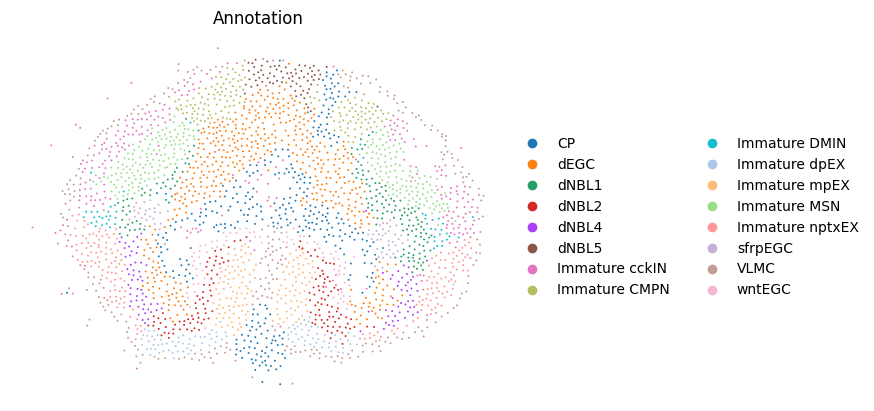

In [ ]:
# 1) make sure the label is categorical
stage_54.obs['Annotation'] = stage_54.obs['Annotation'].astype('category')
stage_54.uns.pop('Annotation_colors', None)

# 3) plot using the XY in obsm['X_spatial']
sc.pl.embedding(
    stage_54,
    basis="spatial",
    color="Annotation",
    size=8,              # dot size
    frameon=False,
    legend_loc = "right margin",
)

In [5]:
stage_44 = data[data.obs['Batch'] == 'Stage44_telencephalon_rep2_FP200000239BL_E4',]

/tmp/ipykernel_3360341/1649620776.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  stage_44.obs['Annotation'] = stage_44.obs['Annotation'].astype('category')


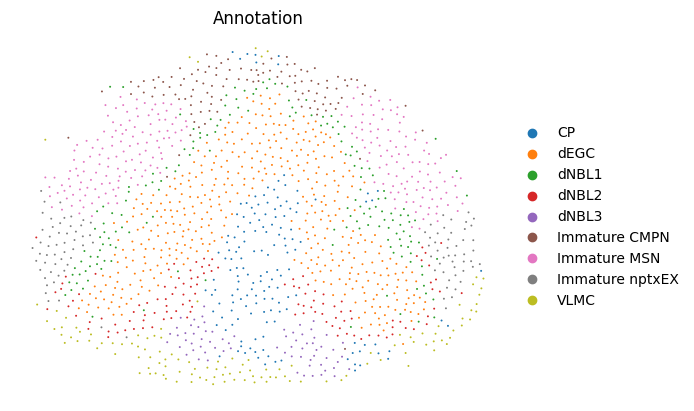

In [6]:
stage_44.obs['Annotation'] = stage_44.obs['Annotation'].astype('category')

stage_44.uns.pop('Annotation_colors', None)
# 3) plot using the XY in obsm['X_spatial']
sc.pl.embedding(
    stage_44,
    basis="spatial",
    color="Annotation",
    size=8,              # dot size
    frameon=False,
    legend_loc = "right margin",
)

In [7]:
 
scvi.settings.seed = 0
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")
base_dir = '/maiziezhou_lab2/yuling/label_Transfer/scVI/Development'
import os.path as osp 
st_data = stage_44
st_data.obs['tech'] = 'st'
sc_adata = stage_54
sc_adata.layers['counts'] = sc_adata.X
sc_adata.obs['tech'] = 'sc'
adata = anndata.concat([st_data, sc_adata])
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata  # keep full dimension safe
sc.pp.highly_variable_genes(
    adata,
    flavor="seurat_v3",
    n_top_genes=2000,
    layer="counts",
    batch_key = "tech",
    subset=True)
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="tech")
scvi_model = scvi.model.SCVI(adata, n_layers=2, n_latent=30)
scvi_model.train(max_epochs=400,
    early_stopping=True,
    early_stopping_patience=20)
SCVI_LATENT_KEY = "X_scVI"
adata.obsm[SCVI_LATENT_KEY] = scvi_model.get_latent_representation()
sc.pp.neighbors(adata, use_rep = SCVI_LATENT_KEY)
sc.tl.umap(adata, min_dist=0.3)
 

Seed set to 0
/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("

Epoch 1/400:   0%|          | 0/400 [00:00<?, ?it/s]

/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/scvi/module/_vae.py:460: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)
/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/scvi/module/_vae.py:460: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)


Epoch 2/400:   0%|          | 1/400 [00:00<05:17,  1.26it/s, v_num=1, train_loss_step=788, train_loss_epoch=875]

/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/scvi/module/_vae.py:460: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)
/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/scvi/module/_vae.py:460: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)


...

Epoch 172/400:  43%|████▎     | 171/400 [01:38<02:12,  1.73it/s, v_num=1, train_loss_step=546, train_loss_epoch=560]

/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/scvi/module/_vae.py:460: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)
/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/scvi/module/_vae.py:460: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)


Epoch 173/400:  43%|████▎     | 172/400 [01:39<02:11,  1.73it/s, v_num=1, train_loss_step=555, train_loss_epoch=560]

/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/scvi/module/_vae.py:460: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)
/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/scvi/module/_vae.py:460: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)


Epoch 173/400:  43%|████▎     | 173/400 [01:40<02:11,  1.73it/s, v_num=1, train_loss_step=582, train_loss_epoch=560]
Monitored metric elbo_validation did not improve in the last 20 records. Best score: 601.196. Signaling Trainer to stop.


In [8]:
SCANVI_CELLTYPE_KEY = "celltype_scanvi"
adata.obs[SCANVI_CELLTYPE_KEY] = "Unknown"
ss2_mask = adata.obs["tech"] == "sc"
adata.obs[SCANVI_CELLTYPE_KEY][ss2_mask] = adata.obs['Annotation'][ss2_mask].values
adata 

/tmp/ipykernel_3360341/3599906138.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  adata.obs[SCANVI_CELLTYPE_KEY][ss2_mask] = adata.obs['Annotation'][ss2_mask].values
/tmp/ipykernel_3360341/3599906138.py:4: SettingWithCopyWarning: 
A valu

AnnData object with n_obs × n_vars = 4406 × 2000
    obs: 'CellID', 'Batch', 'cell_id', 'Annotation', 'tech', '_scvi_batch', '_scvi_labels', 'celltype_scanvi'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap'
    obsm: 'spatial', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [13]:
scvi.model.SCANVI.setup_anndata(
    adata,
    layer = "counts",
    batch_key = 'tech',
    labels_key = "Annotation",
    unlabeled_category="Unknown"
)

/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [17]:
# try to obtain a better latent representation/predictions by using the labels to inform the latent space. 
# all of the query cells will have "celltype_scanvi" of value 'Unknown'
 
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    scvi_model,
    adata = adata,
    unlabeled_category="Unknown",
    labels_key=SCANVI_CELLTYPE_KEY,
)
scanvi_model.train(max_epochs=20, n_samples_per_label=None,   
    batch_size=128)
SCANVI_LATENT_KEY = "X_scANVI"
SCANVI_PREDICTION_KEY = "C_scANVI"

adata.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation(adata)
adata.obs[SCANVI_PREDICTION_KEY] = scanvi_model.predict(adata)
sc.pp.neighbors(adata, use_rep=SCANVI_LATENT_KEY)
sc.tl.umap(adata, min_dist=0.3)
# in order to make colors matchup
adata.obs.C_scANVI = pd.Categorical(
    adata.obs.C_scANVI.values, categories = adata.obs['Annotation'].cat.categories
)
pred = adata[adata.obs[SCANVI_CELLTYPE_KEY] =='Unknown', ]
pred.obs.to_csv(osp.join(base_dir,"label_transfer.csv"), index=True) 

INFO     Training for 20 epochs.                                                                                   


/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.


Epoch 1/20:   0%|          | 0/20 [00:00<?, ?it/s]

/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/scvi/module/_scanvae.py:304: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)
/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/scvi/module/_scanvae.py:304: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)


Epoch 2/20:   5%|▌         | 1/20 [00:01<00:24,  1.30s/it, v_num=1, train_loss_step=621, train_loss_epoch=663]

...

Epoch 20/20:  95%|█████████▌| 19/20 [00:22<00:01,  1.16s/it, v_num=1, train_loss_step=567, train_loss_epoch=552]

/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/scvi/module/_scanvae.py:304: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)
/home/zhuy45/anaconda3/envs/DestVI/lib/python3.9/site-packages/scvi/module/_scanvae.py:304: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)


Epoch 20/20: 100%|██████████| 20/20 [00:23<00:00,  1.16s/it, v_num=1, train_loss_step=541, train_loss_epoch=551]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|██████████| 20/20 [00:23<00:00,  1.17s/it, v_num=1, train_loss_step=541, train_loss_epoch=551]
